# Imports

In [1]:
import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dataset_prep, FISTA, labeled_log_reg, unlabeled_log_reg
importlib.reload(FISTA)
importlib.reload(labeled_log_reg)
importlib.reload(unlabeled_log_reg)
from labeled_log_reg import LabeledLogReg
from unlabeled_log_reg import UnlabeledLogReg
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

RANDOM_SEED = 42
np.random.seed(seed=RANDOM_SEED)

c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Dataset loading

In [2]:
shopping_train, shopping_val, shopping_test = dataset_prep.get_dataset("shopping")

Percentage of labels removed: 14.78%
percentages: 0.15
Percentage of labels removed: 13.13%
percentages: [0.9, 0.05]
Percentage of labels removed: 13.51%
percentages: [0.9, 0.05]
Percentage of labels removed: 10.18%
percentages: [0.9, 0.1, 0.5, 0.05]


In [3]:
smartphone_train, smartphone_val, smartphone_test = dataset_prep.get_dataset("smartphone")

Percentage of labels removed: 15.44%
percentages: 0.15
Percentage of labels removed: 13.76%
percentages: [0.9, 0.05]
Percentage of labels removed: 13.80%
percentages: [0.9, 0.05]
Percentage of labels removed: 16.20%
percentages: [0.9, 0.1, 0.5, 0.05]


In [4]:
software_train, software_val, software_test = dataset_prep.get_dataset("software")

Percentage of labels removed: 13.20%
percentages: 0.15
Percentage of labels removed: 12.60%
percentages: [0.9, 0.05]
Percentage of labels removed: 12.00%
percentages: [0.9, 0.05]
Percentage of labels removed: 10.80%
percentages: [0.9, 0.1, 0.5, 0.05]


In [5]:
wine_train, wine_val, wine_test = dataset_prep.get_dataset("wine")

Percentage of labels removed: 12.96%
percentages: 0.15
Percentage of labels removed: 12.43%
percentages: [0.9, 0.05]
Percentage of labels removed: 13.49%
percentages: [0.9, 0.05]
Percentage of labels removed: 12.78%
percentages: [0.9, 0.1, 0.5, 0.05]


In [6]:
len(np.ones(wine_test.drop(columns=["quality"]).shape[0]))

286

In [7]:
wine_train, wine_val, wine_test = dataset_prep.get_dataset("wine")

Percentage of labels removed: 12.96%
percentages: 0.15
Percentage of labels removed: 12.43%
percentages: [0.9, 0.05]
Percentage of labels removed: 13.49%
percentages: [0.9, 0.05]
Percentage of labels removed: 12.78%
percentages: [0.9, 0.1, 0.5, 0.05]


# Labeled logistic regression
This section runs the custom labeled logistic regression implementation from `labeled_log_reg.py` and compares the FISTA solution with the sklearn baseline. The validation and test feature matrices are aligned to the training columns before fitting so the shapes stay consistent.

### FISTA implementation
Fit the custom FISTA-based logistic lasso model on the training split, choose `lambda` on the validation split, and inspect the evaluation curve and coefficient path. The lambda grid is widened here so the coefficient paths are easier to see.

In [8]:
# target_col = "shopping_preference"
# X_train = shopping_train.drop(columns=[target_col])
# y_train = shopping_train[target_col]
# X_valid = shopping_val.reindex(columns=X_train.columns, fill_value=0)
# y_valid = shopping_val[target_col]

# fista_model = LabeledLogReg(implementation="fista", lambda_grid=[10**i for i in range(-5, 5)])
# fista_model.fit(X_train, y_train)
# fista_result = fista_model.validate(X_valid, y_valid, measure="f_measure")

# print("FISTA best lambda:", fista_result["best_lambda"] )
# print("FISTA validation score:", fista_result["best_score"] )
# fista_pred_proba = fista_model.predict_proba(X_valid)
# fista_pred_proba[:5]

In [9]:
# fista_model.plot("f_measure")
# fista_model.plot_coefficients(feature_names=X_train.columns.tolist())

### sklearn baseline
Run the same train/validation split with the sklearn implementation to compare the selected `lambda` and validation score against the custom FISTA solver.

In [10]:
# TODO: replace this with sklearns logreg
# sklearn_model = LabeledLogReg(implementation="sklearn", n_lambdas=20, max_iter=2000)
# sklearn_model.fit(X_train, y_train)
# sklearn_result = sklearn_model.validate(X_valid, y_valid, measure="f_measure")

# print("sklearn best lambda:", sklearn_result["best_lambda"])
# print("sklearn validation score:", sklearn_result["best_score"])
# sklearn_pred_proba = sklearn_model.predict_proba(X_valid)
# sklearn_pred_proba[:5]



# Experiments

## FISTA vs `sklearn`'s `LogisticRegression`

Firstly, we will take a look on the parameters predicted by our and `sklearn`'s implementation of logistic regression. Moreover, we will see if the optimal lambda parameter is the same in both implementations.

To train these models, we will use fully labeled data (no missingness).

### Profile plots

We want to see how parameter values change with lambda.

c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

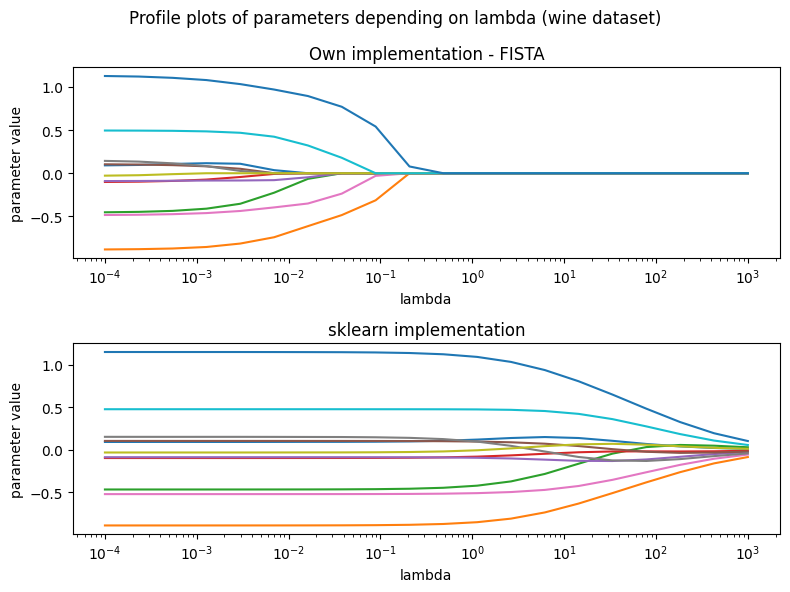

In [11]:
X_train = wine_train.iloc[:, :-5]
y_train = wine_train.iloc[:, -5]

lambdas = [10**i for i in np.linspace(-4, 3, 20)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

fista_model = LabeledLogReg(lambda_grid=lambdas)
fista_model.fit(X_train, y_train)
coefficients_fista = [model.coef for model in fista_model.models_]

sklearn_models = []
coefficients_sklearn = []
for l in lambdas:
    sklearn_model = LogisticRegression(l1_ratio=1, C=1/l, solver="saga")
    sklearn_model.fit(X_train, y_train)
    sklearn_models.append(sklearn_model)
    coefficients_sklearn.append(sklearn_model.coef_.ravel())

for i in range(X_train.shape[1]):
    coef_fista = [x[i] for x in coefficients_fista]
    ax1.plot(lambdas, coef_fista)
    coef_sklearn = [x[i] for x in coefficients_sklearn]
    ax2.plot(lambdas, coef_sklearn)

fig.suptitle("Profile plots of parameters depending on lambda (wine dataset)")
ax1.set_xscale("log")
ax1.set_xlabel("lambda")
ax1.set_ylabel("parameter value")
ax1.set_title("Own implementation - FISTA")
ax2.set_xscale("log")
ax2.set_xlabel("lambda")
ax2.set_ylabel("parameter value")
ax2.set_title("sklearn implementation")
fig.tight_layout()

### Performance comparison

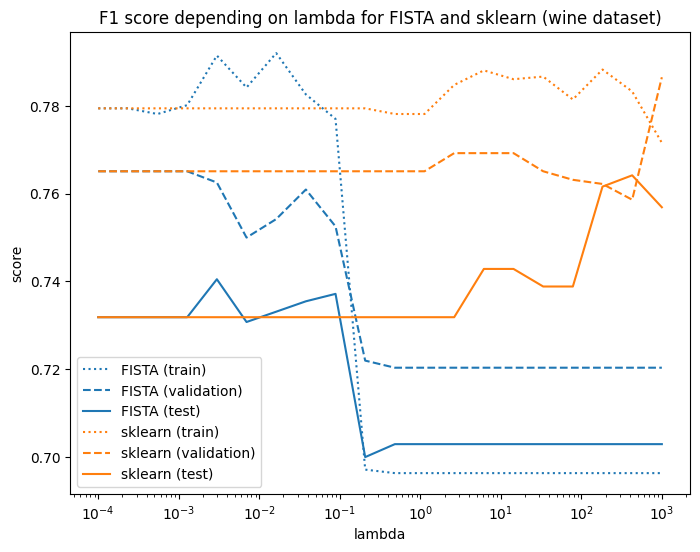

In [12]:
X_val = wine_val.iloc[:, :-1]
y_val = wine_val.iloc[:, -1]
X_test = wine_test.iloc[:, :-1]
y_test = wine_test.iloc[:, -1]

fista_f1_train = fista_model.validate(X_train, y_train, measure="f_measure")["scores"]
fista_f1_val = fista_model.validate(X_val, y_val, measure="f_measure")["scores"]
fista_f1_test = fista_model.validate(X_test, y_test, measure="f_measure")["scores"]

sklearn_f1_train = [f1_score(y_train, model.predict(X_train)) for model in sklearn_models]
sklearn_f1_val = [f1_score(y_val, model.predict(X_val)) for model in sklearn_models]
sklearn_f1_test = [f1_score(y_test, model.predict(X_test)) for model in sklearn_models]

plt.figure(figsize=(8, 6))

plt.plot(lambdas, fista_f1_train, label="FISTA (train)", c="tab:blue", linestyle="dotted")
plt.plot(lambdas, fista_f1_val, label="FISTA (validation)", c="tab:blue", linestyle="dashed")
plt.plot(lambdas, fista_f1_test, label="FISTA (test)", c="tab:blue", linestyle="solid")

plt.plot(lambdas, sklearn_f1_train, label="sklearn (train)", c="tab:orange", linestyle="dotted")
plt.plot(lambdas, sklearn_f1_val, label="sklearn (validation)", c="tab:orange", linestyle="dashed")
plt.plot(lambdas, sklearn_f1_test, label="sklearn (test)", c="tab:orange", linestyle="solid")

plt.xscale("log")
plt.xlabel("lambda")
# plt.ylim(ymin=0.65, ymax=0.8)
plt.ylabel("score")
plt.title("F1 score depending on lambda for FISTA and sklearn (wine dataset)")
plt.legend()

## Missing labels - MCAR

### Constant missingness probability

In [13]:
X_train = shopping_train.iloc[:, :-5]
y_train_full = shopping_train.iloc[:, -5]
y_train = shopping_train.iloc[:, -4]
X_val = shopping_val.iloc[:, :-1]
y_val = shopping_val.iloc[:, -1]
X_test = shopping_test.iloc[:, :-1]
y_test = shopping_test.iloc[:, -1]

In [14]:
labeler = UnlabeledLogReg()

fista_naive = LabeledLogReg()
labeler.fit(fista_naive, X_train, y_train, method="naive")
val_naive = fista_naive.validate(X_val, y_val, measure="f1")
test_naive = fista_naive.validate(X_test, y_test, measure="f1")

fista_knn = LabeledLogReg()
labeler.fit(fista_knn, X_train, y_train, method="knn")
val_knn = fista_knn.validate(X_val, y_val, measure="f1")
test_knn = fista_knn.validate(X_test, y_test, measure="f1")

fista_lda = LabeledLogReg()
labeler.fit(fista_lda, X_train, y_train, method="lda")
val_lda = fista_lda.validate(X_val, y_val, measure="f1")
test_lda = fista_lda.validate(X_test, y_test, measure="f1")

fista_oracle = LabeledLogReg()
labeler.fit(fista_oracle, X_train, y_train_full, method="oracle")
val_oracle = fista_oracle.validate(X_val, y_val, measure="f1")
test_oracle = fista_oracle.validate(X_test, y_test, measure="f1")

In [15]:
val_naive

{'measure': 'f1',
 'lambdas': array([1.92125934e-01, 1.51404128e-01, 1.19313460e-01, 9.40245285e-02,
        7.40956801e-02, 5.83908252e-02, 4.60146727e-02, 3.62616917e-02,
        2.85758913e-02, 2.25191249e-02, 1.77461126e-02, 1.39847581e-02,
        1.10206366e-02, 8.68477169e-03, 6.84400203e-03, 5.39339035e-03,
        4.25024121e-03, 3.34938678e-03, 2.63947180e-03, 2.08002594e-03,
        1.63915671e-03, 1.29173135e-03, 1.01794408e-03, 8.02187051e-04,
        6.32160523e-04, 4.98171749e-04, 3.92582395e-04, 3.09373096e-04,
        2.43800318e-04, 1.92125934e-04]),
 'scores': array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.21634615, 0.55938697, 0.66666667, 0.7299509 , 0.79262673,
        0.84319527, 0.88057554, 0.91188811, 0.92797784, 0.93844049,
        0.94952251, 0.95380435, 0.9660787 , 0.9717362 , 0.97442799,
        0.97849462, 0.98123324, 0.97860963, 0.98128342, 0.97866667,
        0.97736352, 0.97866667, 0.97730307, 0.976     , 0.97463284]),
 'bes

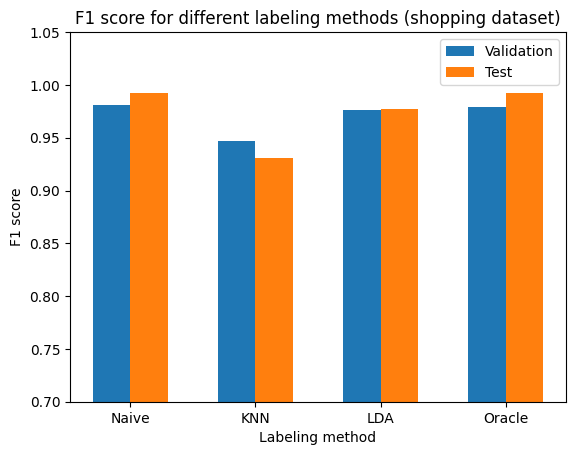

In [16]:
bar_width = 0.3
plt.bar(np.arange(4) - bar_width/2, [val_naive["best_score"], val_knn["best_score"], val_lda["best_score"], val_oracle["best_score"]], bar_width, label="Validation")
plt.bar(np.arange(4) + bar_width/2, [test_naive["best_score"], test_knn["best_score"], test_lda["best_score"], test_oracle["best_score"]], bar_width, label="Test")
plt.xticks(np.arange(4), ["Naive", "KNN", "LDA", "Oracle"])
plt.xlabel("Labeling method")
plt.ylim(ymin=0.7, ymax=1.05)
plt.ylabel("F1 score")
plt.title("F1 score for different labeling methods (shopping dataset)")
plt.legend(loc="upper right")

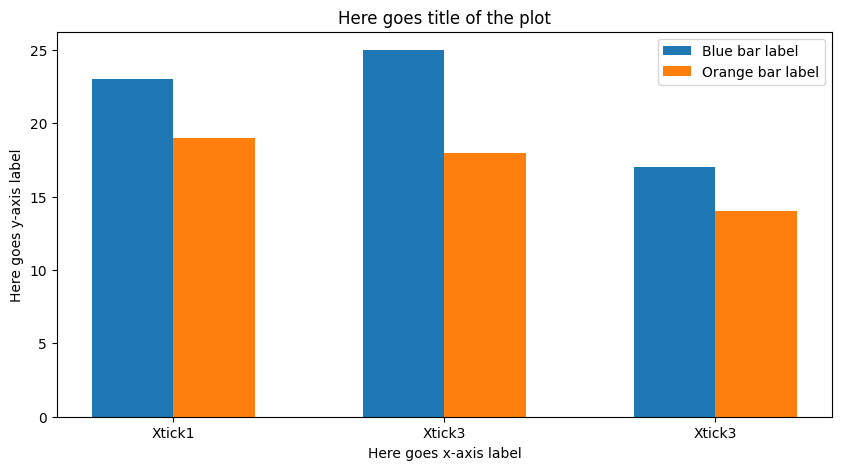

In [17]:
# Numbers of pairs of bars you want
N = 3

# Data on X-axis

# Specify the values of blue bars (height)
blue_bar = (23, 25, 17)
# Specify the values of orange bars (height)
orange_bar = (19, 18, 14)

# Position of bars on x-axis
ind = np.arange(N)

# Figure size
plt.figure(figsize=(10,5))

# Width of a bar 
width = 0.3       

# Plotting
plt.bar(ind, blue_bar , width, label='Blue bar label')
plt.bar(ind + width, orange_bar, width, label='Orange bar label')

plt.xlabel('Here goes x-axis label')
plt.ylabel('Here goes y-axis label')
plt.title('Here goes title of the plot')

# xticks()
# First argument - A list of positions at which ticks should be placed
# Second argument -  A list of labels to place at the given locations
plt.xticks(ind + width / 2, ('Xtick1', 'Xtick3', 'Xtick3'))

# Finding the best position for legends and putting it
plt.legend(loc='best')
plt.show()


### Time plots


=== Dataset: smartphone  |  Deletion: mcar ===

Percentage of labels removed: 15.44%
percentages: 0.15
Percentage of labels removed: 13.76%
percentages: [0.9, 0.05]
Percentage of labels removed: 13.80%
percentages: [0.9, 0.05]
Percentage of labels removed: 16.20%
percentages: [0.9, 0.1, 0.5, 0.05]
  primary rate = 0.05  |  tolerance ratio = 0.10
Percentage of labels removed: 5.16%
percentages: 0.05
     naive: F1 = 0.9610
       knn: F1 = 0.9611
       lda: F1 = 0.9593
    oracle: F1 = 0.9610
  primary rate = 0.12  |  tolerance ratio = 0.10
Percentage of labels removed: 11.84%
percentages: 0.11538461538461539
     naive: F1 = 0.9580
       knn: F1 = 0.9610
       lda: F1 = 0.9585
    oracle: F1 = 0.9610
  primary rate = 0.18  |  tolerance ratio = 0.10
Percentage of labels removed: 18.64%
percentages: 0.1807692307692308
     naive: F1 = 0.9592
       knn: F1 = 0.9637
       lda: F1 = 0.9608
    oracle: F1 = 0.9610
  primary rate = 0.25  |  tolerance ratio = 0.10
Percentage of labels re

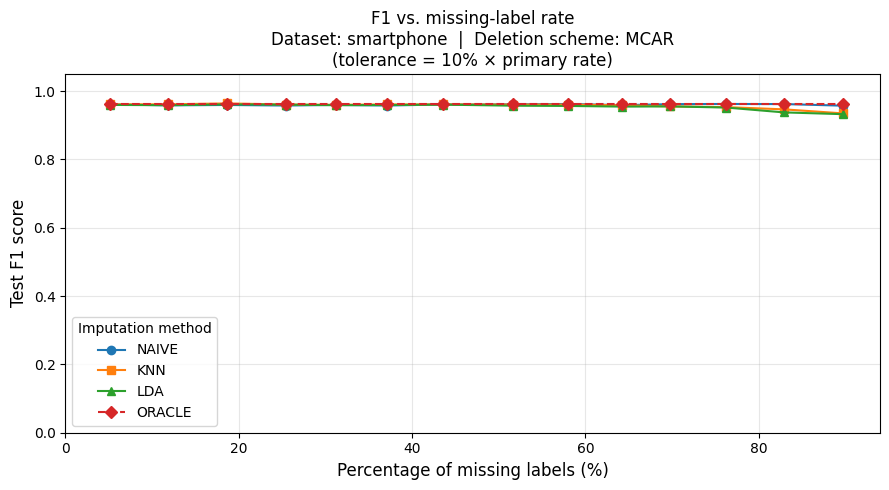

In [24]:
"""
plot_f1_vs_missing.py
---------------------
Inputs  : DATASET             – one of "shopping", "smartphone", "software", "wine"
          LABEL_DELETION_METHOD – one of "mcar", "mar1", "mar2", "mnar"
Output  : a line plot showing test F1 for naive / knn / lda / oracle as the
          percentage of missing labels increases.

Constraint: the "tolerance" probability (the secondary / background missing
probability) is tied to the primary rate via a fixed ratio:
    tolerance = primary_rate * TOLERANCE_RATIO
This keeps the secondary missingness proportional to the sweep variable.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

from dataset_prep import get_dataset, remove_labels
from labeled_log_reg import LabeledLogReg
from unlabeled_log_reg import UnlabeledLogReg

# ── Configuration ─────────────────────────────────────────────────────────────

DATASET               = "smartphone"          # "shopping" | "smartphone" | "software" | "wine"
LABEL_DELETION_METHOD = "mcar"          # "mcar" | "mar1" | "mar2" | "mnar"

# The tolerance probability is tolerance = primary_rate * TOLERANCE_RATIO.
# At a primary rate of 0.50 this gives tolerance = 0.05 (i.e. ~10 % of primary).
TOLERANCE_RATIO = 0.10

# Sweep: primary missing-label probabilities to evaluate.
PRIMARY_RATES = np.linspace(0.05, 0.90, 14)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Helper: build p_xxx arguments from primary rate ───────────────────────────

def build_params(method: str, p: float):
    """Return keyword-argument dict for remove_labels given primary rate p."""
    tol = p * TOLERANCE_RATIO
    if method == "mcar":
        return dict(p_mcar=p)
    elif method in ("mar1", "mar2"):
        # p_mar[0] = chosen-decile rate, p_mar[1] = background rate (tolerance)
        return dict(p_mar=[p, tol])
    elif method == "mnar":
        # class-1 chosen decile, class-1 background, class-0 chosen decile, class-0 background
        # Class-0 missingness kept lower to keep asymmetry meaningful.
        return dict(p_mnar=[p, tol, p * 0.5, tol * 0.5])
    else:
        raise ValueError(f"Unknown method: {method}")


# ── Helper: get base dataset once, then re-apply label removal each sweep ─────

def load_base(dataset_name: str):
    """
    Load the dataset without label-removal columns (oracle split only).
    Returns (X_train_raw, y_train_full, X_val, y_val, X_test, y_test,
             train_df_raw, target_col).
    """
    # get_dataset always adds the four missing-label columns; we keep the raw
    # train split and ignore those extra columns here.
    train_df, val_df, test_df = get_dataset(dataset_name)

    target_col = {
        "shopping":   "shopping_preference",
        "smartphone": "target_action",
        "software":   "DEFECT_LABEL",
        "wine":       "quality",
    }[dataset_name]

    # Features: drop target + any derived missing-label columns
    feature_cols = [c for c in train_df.columns
                    if c == target_col or not c.startswith(target_col + "_")]
    train_clean = train_df[feature_cols].copy()

    X_train = train_clean.drop(columns=[target_col])
    y_train_full = train_clean[target_col].to_numpy()

    X_val  = val_df.drop(columns=[target_col])
    y_val  = val_df[target_col].to_numpy()
    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col].to_numpy()

    return X_train, y_train_full, X_val, y_val, X_test, y_test, train_clean, target_col


def run_sweep(dataset_name: str, deletion_method: str):
    print(f"\n=== Dataset: {dataset_name}  |  Deletion: {deletion_method} ===\n")

    X_train, y_train_full, X_val, y_val, X_test, y_test, train_clean, target_col = \
        load_base(dataset_name)

    methods       = ["naive", "knn", "lda", "oracle"]
    results       = {m: [] for m in methods}
    actual_rates  = []

    labeler = UnlabeledLogReg()

    for p in PRIMARY_RATES:
        params = build_params(deletion_method, p)
        print(f"  primary rate = {p:.2f}  |  tolerance ratio = {TOLERANCE_RATIO:.2f}")

        # Apply label removal to a fresh copy of the training data
        df_tmp = remove_labels(train_clean.copy(), target_col, deletion_method, **params)
        y_missing = df_tmp[f"{target_col}_{deletion_method}"].to_numpy()

        actual_missing_pct = (y_missing == -1).mean()
        actual_rates.append(actual_missing_pct)

        for method in methods:
            model = LabeledLogReg()
            try:
                if method == "oracle":
                    model = labeler.fit(model, X_train.to_numpy(), y_train_full, method="oracle")
                else:
                    model = labeler.fit(model, X_train.to_numpy(), y_missing, method=method)

                model.validate(X_val, y_val, measure="f1")
                y_pred = model.predict(X_test)
                score  = f1_score(y_test, y_pred, zero_division=0)
            except Exception as exc:
                print(f"    [{method}] failed at p={p:.2f}: {exc}")
                score = float("nan")

            results[method].append(score)
            print(f"    {method:>6}: F1 = {score:.4f}")

    return np.array(actual_rates), results


def plot_results(actual_rates, results, dataset_name, deletion_method):
    fig, ax = plt.subplots(figsize=(9, 5))

    styles = {
        "naive":  dict(color="tab:blue",   linestyle="-",  marker="o"),
        "knn":    dict(color="tab:orange",  linestyle="-",  marker="s"),
        "lda":    dict(color="tab:green",   linestyle="-",  marker="^"),
        "oracle": dict(color="tab:red",     linestyle="--", marker="D"),
    }

    for method, scores in results.items():
        ax.plot(actual_rates * 100, scores,
                label=method.upper(), **styles[method])

    ax.set_xlabel("Percentage of missing labels (%)", fontsize=12)
    ax.set_ylabel("Test F1 score", fontsize=12)
    ax.set_title(
        f"F1 vs. missing-label rate\n"
        f"Dataset: {dataset_name}  |  Deletion scheme: {deletion_method.upper()}\n"
        f"(tolerance = {TOLERANCE_RATIO:.0%} × primary rate)",
        fontsize=12,
    )
    ax.legend(title="Imputation method", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)
    ax.set_ylim(0, 1.05)

    plt.tight_layout()

    fname = f"f1_vs_missing_{dataset_name}_{deletion_method}.png"
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"\nPlot saved to: {fname}")
    plt.show()


# ── Entry point ───────────────────────────────────────────────────────────────

if __name__ == "__main__":
    actual_rates, results = run_sweep(DATASET, LABEL_DELETION_METHOD)
    plot_results(actual_rates, results, DATASET, LABEL_DELETION_METHOD)

In [ ]:
#xd